# ICU Length of Stay — Pipeline ML (MIMIC-III)

**Objetivo:** Análise estatística de eventos clínicos de doentes em UCI e previsão do tempo de internamento (*length of stay*) usando um pipeline de Machine Learning distribuído com PySpark.

**Dataset:** MIMIC-III — `CHARTEVENTS.csv.gz` (~4.2 GB comprimido, ~330M linhas)

**Pipeline:**
1. Setup do ambiente (Java 21 + PySpark 4.1.2)
2. Ingestão e conversão para Parquet
3. Análise estatística e visualização por paciente
4. Pré-processamento e feature engineering
5. Preparação dos dados para ML
6. Treino e validação de modelos
7. Análise de resultados
8. Performance e profiling

---
## Capítulo 0 — Setup do Ambiente

Configuração do Java 21, PySpark 4.1.2 e sessão Spark com parâmetros ajustados à RAM disponível


In [40]:
import os
import subprocess
import psutil

# --- Java 21 (obrigatório para PySpark 4.x) ---
JAVA_HOME = r"C:\Program Files\Eclipse Adoptium\jdk-21.0.11.10-hotspot"
os.environ["JAVA_HOME"] = JAVA_HOME
os.environ["PATH"] = JAVA_HOME + r"\bin;" + os.environ["PATH"]

java_ver = subprocess.run(["java", "-version"], capture_output=True, text=True).stderr
print(java_ver)
assert "21" in java_ver, "Java 21 nao encontrado — verifica o caminho JAVA_HOME"

HADOOP_HOME = r"C:\hadoop"
os.environ["HADOOP_HOME"] = HADOOP_HOME
os.environ["PATH"] = HADOOP_HOME + r"\bin;" + os.environ["PATH"]
print(f"HADOOP_HOME: {HADOOP_HOME}")


openjdk version "21.0.11" 2026-04-21 LTS
OpenJDK Runtime Environment Temurin-21.0.11+10 (build 21.0.11+10-LTS)
OpenJDK 64-Bit Server VM Temurin-21.0.11+10 (build 21.0.11+10-LTS, mixed mode, sharing)

HADOOP_HOME: C:\hadoop


In [41]:
import urllib.request
from pathlib import Path

# --- Descarregar winutils.exe e hadoop.dll
hadoop_bin = Path(r"C:\hadoop\bin")
hadoop_bin.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://github.com/cdarlint/winutils/raw/master/hadoop-3.3.6/bin"
files = ["winutils.exe", "hadoop.dll"]

for fname in files:
    dest = hadoop_bin / fname
    if not dest.exists():
        print(f"A descarregar {fname}...")
        urllib.request.urlretrieve(f"{BASE_URL}/{fname}", dest)
        print(f"  -> guardado em {dest}")
    else:
        print(f"  {fname} já existe — OK")

print("\n Spark pronto a ser criado.")


  winutils.exe já existe — OK
  hadoop.dll já existe — OK

 Spark pronto a ser criado.


In [42]:
# --- Diagnóstico de memória ---
ram = psutil.virtual_memory()
print(f"RAM total:      {ram.total / 1e9:.1f} GB")
print(f"RAM disponível: {ram.available / 1e9:.1f} GB")
print(f"RAM usada:      {ram.percent}%")

RAM total:      34.2 GB
RAM disponível: 11.3 GB
RAM usada:      67.0%


In [43]:
from pyspark.sql import SparkSession

# Encerrar sessão anterior se existir
existing = SparkSession.getActiveSession()
if existing:
    existing.stop()

# --- Criar sessão Spark optimizada para 34 GB RAM ---
spark = SparkSession.builder \
    .appName("ICU_LOS") \
    .master("local[*]") \
    .config("spark.driver.memory",          "16g") \
    .config("spark.executor.memory",        "4g")  \
    .config("spark.driver.maxResultSize",   "4g")  \
    .config("spark.sql.shuffle.partitions", "16")  \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print(f"Spark UI: http://localhost:4040")

Spark version: 4.1.2
Spark UI: http://localhost:4040


---
## Capítulo 1 — Ingestão dos Dados

Leitura do `CHARTEVENTS.csv.gz` com schema explícito (evita `inferSchema` que percorre o ficheiro inteiro).
Na primeira execução converte para **Parquet** particionado por `SUBJECT_ID` — 10-20x mais rápido em todas as operações seguintes.

| Ficheiro | Tamanho | Descrição |
|---|---|---|
| `CHARTEVENTS.csv.gz` | ~4.2 GB | Eventos clínicos de doentes em UCI |
| `D_ITEMS.csv.gz` | ~1 MB | Dicionário de items (ITEMID → descrição) |
| `ADMISSIONS.csv.gz` | ~10 MB | Admissões hospitalares (datas entrada/saída) |


In [44]:
from pathlib import Path
from pyspark.sql.types import StructType, StructField, IntegerType, StringType, DoubleType

data_dir   = Path.cwd()
chart_path = data_dir / "CHARTEVENTS.csv.gz"
items_path = data_dir / "D_ITEMS.csv.gz"
adm_path   = data_dir / "ADMISSIONS.csv.gz"
parquet_path = data_dir / "CHARTEVENTS.parquet"

if not chart_path.exists():
    raise FileNotFoundError(f"Ficheiro nao encontrado: {chart_path}")

def spark_path(path: Path) -> str:
    """Converte Path para URI compatível com Spark no Windows."""
    return path.resolve().as_uri()

In [45]:
# --- Schema explícito: evita inferSchema (poupa ~2 min) ---
chart_schema = StructType([
    StructField("ROW_ID",       IntegerType(), True),
    StructField("SUBJECT_ID",   IntegerType(), True),
    StructField("HADM_ID",      IntegerType(), True),
    StructField("ICUSTAY_ID",   IntegerType(), True),
    StructField("ITEMID",       IntegerType(), True),
    StructField("CHARTTIME",    StringType(),  True),
    StructField("STORETIME",    StringType(),  True),
    StructField("CGID",         IntegerType(), True),
    StructField("VALUE",        StringType(),  True),
    StructField("VALUENUM",     DoubleType(),  True),
    StructField("VALUEUOM",     StringType(),  True),
    StructField("WARNING",      IntegerType(), True),
    StructField("ERROR",        IntegerType(), True),
    StructField("RESULTSTATUS", StringType(),  True),
    StructField("STOPPED",      StringType(),  True),
])

try:
    df_chart = spark.read \
        .option("header", True) \
        .schema(chart_schema) \
        .csv(spark_path(chart_path))
    print(f"CHARTEVENTS colunas: {len(df_chart.columns)}")
    print(df_chart.columns)
except Exception as e:
    print(f"ERRO: {type(e).__name__}: {e}")

df_items = spark.read.option("header", True).csv(spark_path(items_path)) if items_path.exists() else None
df_adm   = spark.read.option("header", True).csv(spark_path(adm_path))   if adm_path.exists() else None

if df_items is None: print(f"Aviso: ficheiro ausente -> {items_path.name}")
if df_adm   is None: print(f"Aviso: ficheiro ausente -> {adm_path.name}")

CHARTEVENTS colunas: 15
['ROW_ID', 'SUBJECT_ID', 'HADM_ID', 'ICUSTAY_ID', 'ITEMID', 'CHARTTIME', 'STORETIME', 'CGID', 'VALUE', 'VALUENUM', 'VALUEUOM', 'WARNING', 'ERROR', 'RESULTSTATUS', 'STOPPED']


In [46]:
import time

# --- Converter para Parquet ---
# O Parquet é colunar, comprimido e paralelizável
# partitionBy(SUBJECT_ID) permite queries por paciente sem ler o ficheiro todo

if not parquet_path.exists():
    print("A converter CHARTEVENTS.csv.gz para Parquet...")
    print("Acompanha o progresso em http://localhost:4040\n")
    t0 = time.time()

    df_chart.write \
        .mode("overwrite") \
        .partitionBy("SUBJECT_ID") \
        .parquet(spark_path(parquet_path))

    print(f"Conversão concluída em {(time.time()-t0)/60:.1f} min")
    print(f"Parquet guardado em: {parquet_path}")
else:
    print(f"Parquet já existe — a carregar de: {parquet_path}")

# Recarregar sempre a partir do Parquet
df_chart = spark.read.parquet(spark_path(parquet_path))
print(f"\nColunas: {df_chart.columns}")


Parquet já existe — a carregar de: c:\Users\Admin\Desktop\MIMIC-EDU\CHARTEVENTS.parquet



Colunas: ['ROW_ID', 'HADM_ID', 'ICUSTAY_ID', 'ITEMID', 'CHARTTIME', 'STORETIME', 'CGID', 'VALUE', 'VALUENUM', 'VALUEUOM', 'WARNING', 'ERROR', 'RESULTSTATUS', 'STOPPED', 'SUBJECT_ID']


---
## Capítulo 2 — Análise Estatística e Visualização

Análise exploratória por `SUBJECT_ID` e `ICUSTAY_ID`:
- Estatísticas descritivas por estadia (contagem, média, desvio padrão, min, max)
- Identificação de outliers nos valores clínicos
- Visualização temporal de eventos por paciente


### 2.1 Estatísticas descritivas por SUBJECT_ID / ICUSTAY_ID

In [ ]:
from pyspark.sql.functions import col, count, mean, stddev, min, max

stats = df_chart.groupBy("SUBJECT_ID", "ICUSTAY_ID") \
    .agg(
        count("*")         .alias("n_events"),
        mean("VALUENUM")   .alias("mean_val"),
        stddev("VALUENUM") .alias("std_val"),
        min("VALUENUM")    .alias("min_val"),
        max("VALUENUM")    .alias("max_val"),
    )

try:
    stats.show(5, truncate=False)
except Exception as e:
    print(f"ERRO: {type(e).__name__}: {e}")

+----------+----------+--------+-----------------+------------------+-------------------+-------+
|SUBJECT_ID|ICUSTAY_ID|n_events|mean_val         |std_val           |min_val            |max_val|
+----------+----------+--------+-----------------+------------------+-------------------+-------+
|11923     |275574    |9441    |83.30789288587081|277.75615496457925|-45.0              |7287.0 |
|6365      |234114    |12082   |55.55573996303061|67.2032641132314  |-0.4000000059604645|637.0  |
|27427     |246501    |11961   |86.03696792114553|199.81132649532066|-4.0               |3000.0 |
|27427     |203143    |72753   |58.29286704384683|197.16744889848292|-250.0             |4717.0 |
|27427     |207593    |3246    |35.07726799653081|87.7039924613364  |0.0                |2500.0 |
+----------+----------+--------+-----------------+------------------+-------------------+-------+
only showing top 5 rows


### 2.2 Identificação de outliers

Valores com `std_val` muito elevado ou `max_val` extremo indicam outliers que precisam de tratamento no pré-processamento.
Exemplo observado: `SUBJECT_ID=671` com `max_val=219219` e `std_val=4028`.

In [48]:
from pyspark.sql.functions import desc, percentile_approx, expr

# Top 10 estadias com maior variabilidade — candidatos a outliers
stats.orderBy(desc("std_val")).show(10, truncate=False)

+----------+----------+--------+------------------+------------------+-------+---------+
|SUBJECT_ID|ICUSTAY_ID|n_events|mean_val          |std_val           |min_val|max_val  |
+----------+----------+--------+------------------+------------------+-------+---------+
|32005     |202559    |1216    |14724.338162544173|349251.88667708816|0.0    |8309010.0|
|92373     |256824    |4201    |5625.00158862876  |236094.88097281184|-7.0   |9999999.0|
|49615     |298310    |3932    |4941.945817025436 |221185.87541353135|-3.0   |9999999.0|
|60552     |221208    |4506    |5383.225067961165 |209630.0882386926 |-10.0  |8239872.0|
|66405     |287031    |9949    |2568.9220335551086|147200.61722118082|-4.0   |8654765.1|
|71011     |228194    |3095    |3027.78019520852  |99290.64099438276 |-4.0   |3333331.0|
|48882     |224325    |15726   |1125.9171559750023|94964.32316747136 |-14.0  |8409010.0|
|84020     |210970    |2414    |2664.6301306620203|88519.50170561095 |-3.0   |2999280.0|
|40124     |279554   

#### 2.2.1 Cálculo de outliers por IQR para os ITEMIDs mais frequentes

In [49]:
import pandas as pd
import numpy as np

# Seleccionar top ITEMIDs para análise de outliers
TOP_N_ITEMS = 8

top_items_counts = df_chart.groupBy("ITEMID") \
    .count() \
    .orderBy(desc("count")) \
    .limit(TOP_N_ITEMS) \
    .toPandas()

top_item_ids = top_items_counts["ITEMID"].tolist()
print(f"Top {TOP_N_ITEMS} ITEMIDs: {top_item_ids}")

# Recolher amostra para análise em pandas
df_sample = df_chart.filter(col("ITEMID").isin(top_item_ids)) \
    .select("ITEMID", "VALUENUM") \
    .dropna(subset=["VALUENUM"]) \
    .toPandas()

# Calcular limites IQR por ITEMID
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

bounds = {}
for item in top_item_ids:
    vals = df_sample[df_sample["ITEMID"] == item]["VALUENUM"]
    lo, hi = iqr_bounds(vals)
    n_out = ((vals < lo) | (vals > hi)).sum()
    bounds[item] = {"lo": lo, "hi": hi, "n_outliers": n_out, "pct": n_out / len(vals) * 100}
    print(f"ITEM {item:>7}: [{lo:.1f}, {hi:.1f}]  outliers={n_out} ({n_out/len(vals)*100:.1f}%)")

Top 8 ITEMIDs: [211, 742, 646, 618, 212, 161, 128, 550]
ITEM     211: [-16.0, 240.0]  outliers=64 (0.0%)
ITEM     742: [1.0, 1.0]  outliers=0 (0.0%)
ITEM     646: [90.0, 106.0]  outliers=59521 (1.7%)
ITEM     618: [4.0, 36.0]  outliers=64765 (1.9%)
ITEM     212: [nan, nan]  outliers=0 (nan%)
ITEM     161: [nan, nan]  outliers=0 (nan%)
ITEM     128: [nan, nan]  outliers=0 (nan%)
ITEM     550: [nan, nan]  outliers=0 (nan%)


C:\Users\Admin\AppData\Local\Temp\ipykernel_25900\2044035399.py:33: RuntimeWarning: invalid value encountered in scalar divide
  bounds[item] = {"lo": lo, "hi": hi, "n_outliers": n_out, "pct": n_out / len(vals) * 100}
C:\Users\Admin\AppData\Local\Temp\ipykernel_25900\2044035399.py:34: RuntimeWarning: invalid value encountered in scalar divide
  print(f"ITEM {item:>7}: [{lo:.1f}, {hi:.1f}]  outliers={n_out} ({n_out/len(vals)*100:.1f}%)")
C:\Users\Admin\AppData\Local\Temp\ipykernel_25900\2044035399.py:33: RuntimeWarning: invalid value encountered in scalar divide
  bounds[item] = {"lo": lo, "hi": hi, "n_outliers": n_out, "pct": n_out / len(vals) * 100}
C:\Users\Admin\AppData\Local\Temp\ipykernel_25900\2044035399.py:34: RuntimeWarning: invalid value encountered in scalar divide
  print(f"ITEM {item:>7}: [{lo:.1f}, {hi:.1f}]  outliers={n_out} ({n_out/len(vals)*100:.1f}%)")
C:\Users\Admin\AppData\Local\Temp\ipykernel_25900\2044035399.py:33: RuntimeWarning: invalid value encountered in scala

#### 2.2.2 Boxplot — Distribuição e outliers por ITEMID

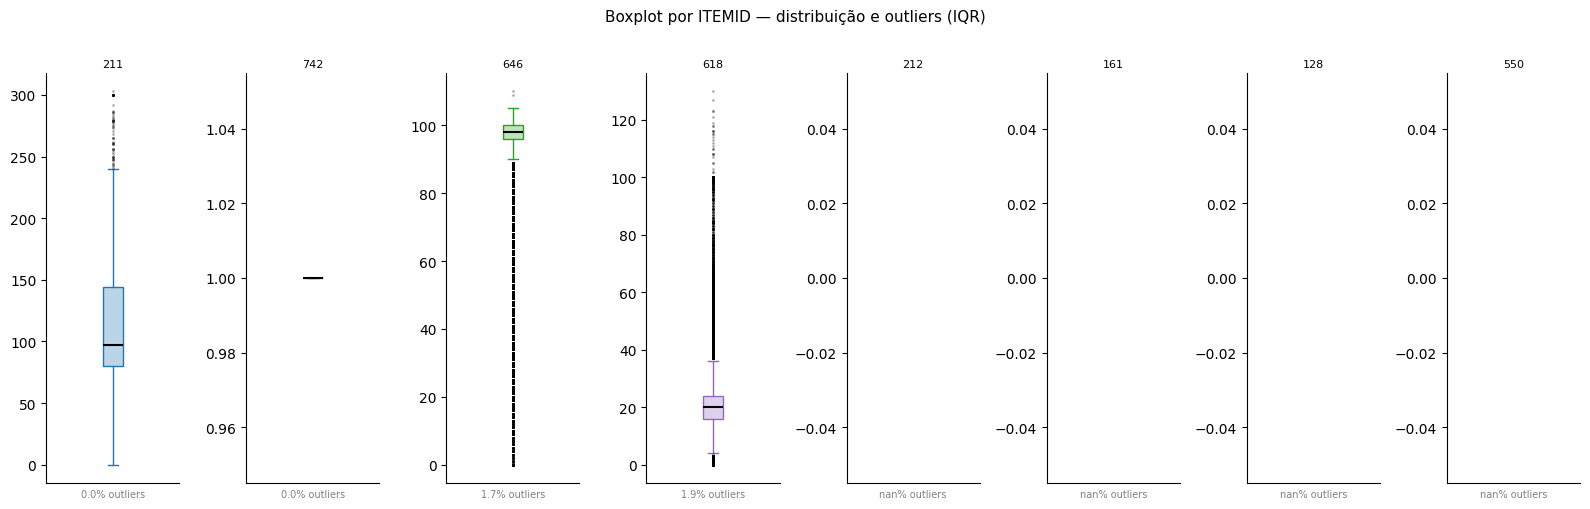

In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

ITEM_LABELS = {
    220045: "FC (bpm)",
    220050: "PAS invasiva (mmHg)",
    220051: "PAD invasiva (mmHg)",
    220052: "PAM invasiva (mmHg)",
    220179: "PAS não-invasiva (mmHg)",
    220180: "PAD não-invasiva (mmHg)",
    220210: "FR (rpm)",
    220277: "SpO2 (%)",
    220739: "GCS — olhos",
    223753: "GCS — motor",
    223762: "Temperatura (°C)",
}

fig, axes = plt.subplots(1, len(top_item_ids), figsize=(16, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(top_item_ids)))

for ax, item, color in zip(axes, top_item_ids, colors):
    vals = df_sample[df_sample["ITEMID"] == item]["VALUENUM"].dropna()
    bp = ax.boxplot(vals, patch_artist=True, notch=False,
                    flierprops=dict(marker=".", markersize=2, alpha=0.3, color=color),
                    medianprops=dict(color="black", linewidth=1.5),
                    boxprops=dict(facecolor=(*color[:3], 0.3), edgecolor=color),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color))
    label = ITEM_LABELS.get(item, str(item))
    ax.set_title(label, fontsize=8, pad=4)
    ax.set_xticks([])
    ax.spines[["top", "right"]].set_visible(False)
    pct = bounds[item]["pct"]
    ax.set_xlabel(f"{pct:.1f}% outliers", fontsize=7, color="gray")

fig.suptitle("Boxplot por ITEMID — distribuição e outliers (IQR)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("viz_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2.2.3 Scatter antes vs. depois da remoção de outliers

C:\Users\Admin\AppData\Local\Temp\ipykernel_25900\906440764.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\Admin\AppData\Local\Temp\ipykernel_25900\906440764.py:32: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("viz_outliers_before_after.png", dpi=150, bbox_inches="tight")
c:\Users\Admin\Desktop\MIMIC-EDU\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


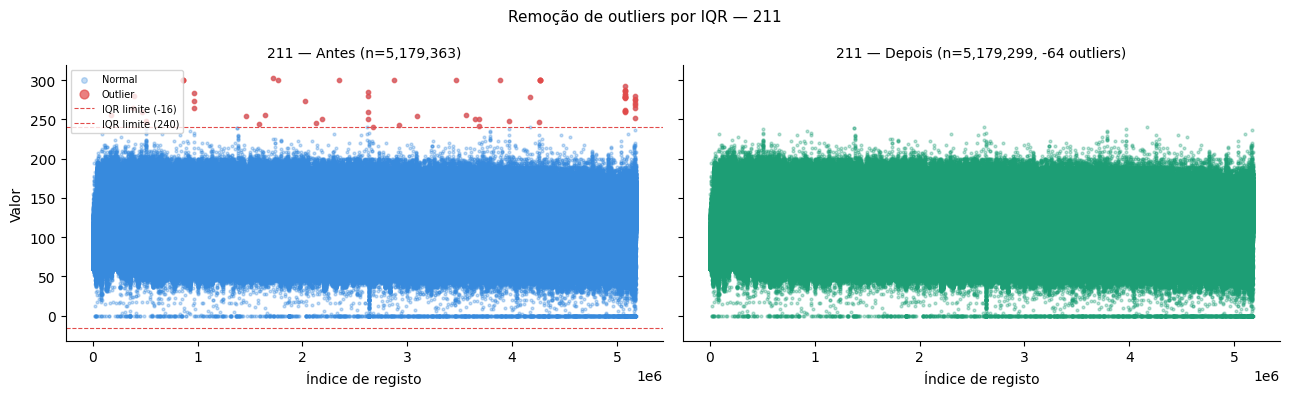

In [51]:
# Seleccionar um ITEMID representativo para comparação visual
ITEM_COMPARE = top_item_ids[0]  # ex: FC (bpm)
label_compare = ITEM_LABELS.get(ITEM_COMPARE, str(ITEM_COMPARE))

vals_all = df_sample[df_sample["ITEMID"] == ITEM_COMPARE]["VALUENUM"].reset_index(drop=True)
lo, hi = bounds[ITEM_COMPARE]["lo"], bounds[ITEM_COMPARE]["hi"]
mask_ok = (vals_all >= lo) & (vals_all <= hi)
vals_clean = vals_all[mask_ok]
vals_out   = vals_all[~mask_ok]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# --- Antes ---
axes[0].scatter(range(len(vals_all)), vals_all, s=4, alpha=0.3, color="#378ADD", label="Normal")
axes[0].scatter(vals_out.index, vals_out, s=10, alpha=0.7, color="#E24B4A", label="Outlier", zorder=3)
axes[0].axhline(lo, color="#E24B4A", linestyle="--", linewidth=0.8, label=f"IQR limite ({lo:.0f})")
axes[0].axhline(hi, color="#E24B4A", linestyle="--", linewidth=0.8, label=f"IQR limite ({hi:.0f})")
axes[0].set_title(f"{label_compare} — Antes (n={len(vals_all):,})", fontsize=10)
axes[0].set_xlabel("Índice de registo")
axes[0].set_ylabel("Valor")
axes[0].legend(fontsize=7, markerscale=2)
axes[0].spines[["top", "right"]].set_visible(False)

# --- Depois ---
axes[1].scatter(range(len(vals_clean)), vals_clean, s=4, alpha=0.3, color="#1D9E75")
axes[1].set_title(f"{label_compare} — Depois (n={len(vals_clean):,}, -{len(vals_out):,} outliers)", fontsize=10)
axes[1].set_xlabel("Índice de registo")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Remoção de outliers por IQR — {label_compare}", fontsize=11)
plt.tight_layout()
plt.savefig("viz_outliers_before_after.png", dpi=150, bbox_inches="tight")
plt.show()


#### 2.2.4 Histograma — Distribuição antes e depois da remoção de outliers

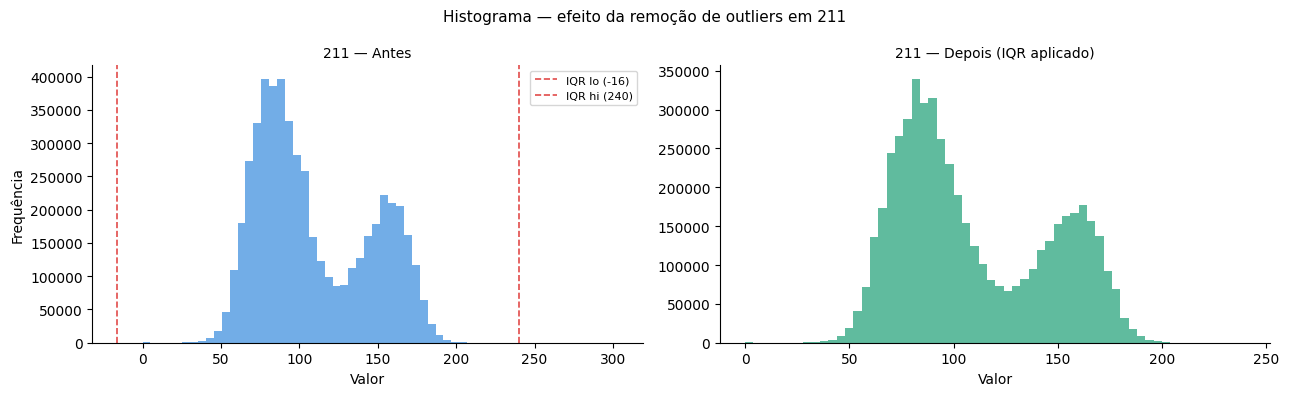

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bins_hist = 60

axes[0].hist(vals_all, bins=bins_hist, color="#378ADD", alpha=0.7, edgecolor="none")
axes[0].axvline(lo, color="#E24B4A", linestyle="--", linewidth=1.2, label=f"IQR lo ({lo:.0f})")
axes[0].axvline(hi, color="#E24B4A", linestyle="--", linewidth=1.2, label=f"IQR hi ({hi:.0f})")
axes[0].set_title(f"{label_compare} — Antes", fontsize=10)
axes[0].set_xlabel("Valor")
axes[0].set_ylabel("Frequência")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(vals_clean, bins=bins_hist, color="#1D9E75", alpha=0.7, edgecolor="none")
axes[1].set_title(f"{label_compare} — Depois (IQR aplicado)", fontsize=10)
axes[1].set_xlabel("Valor")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Histograma — efeito da remoção de outliers em {label_compare}", fontsize=11)
plt.tight_layout()
plt.savefig("viz_histogram_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.3 Visualização temporal por ICUSTAY_ID

Scatter plot dos sinais vitais de uma estadia UCI (`ICUSTAY_ID = 200072`), com o tempo
normalizado no eixo X (0 = admissão, 1 = alta) e o valor de cada métrica no eixo Y.

Os registos são agrupados em bins de 0.2 e agregados pela média, reduzindo o ruído dos
registos individuais. Cada subplot corresponde a um dos 8 ITEMIDs mais frequentes,
com o nome clínico mapeado via dicionário `ITEM_LABELS`.

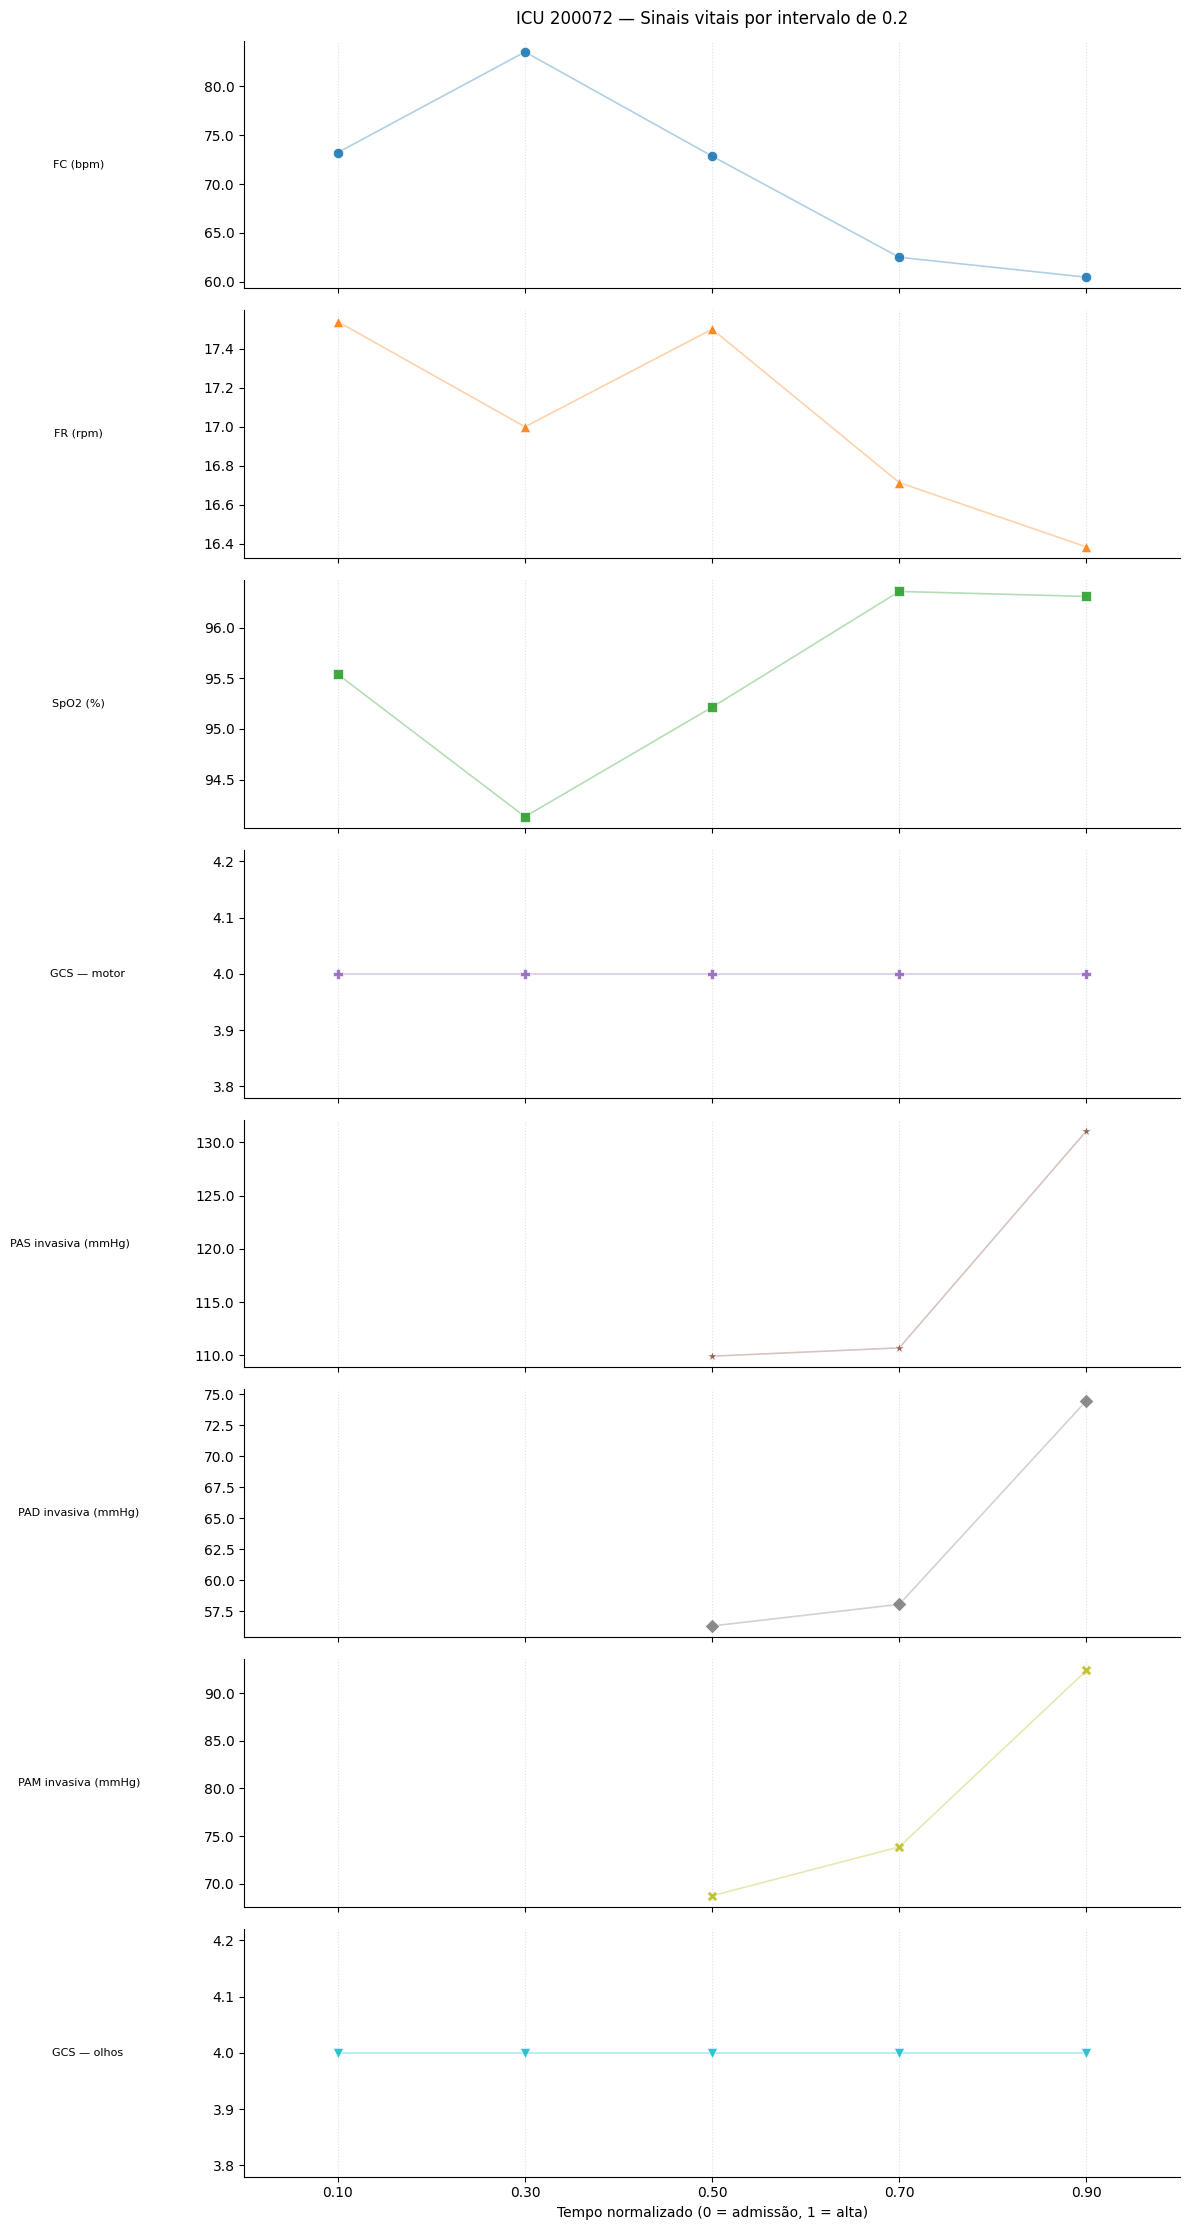

Gráfico guardado em viz_patient_scatter.png


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

ICUSTAY_ID_EXAMPLE = 200072
BIN_SIZE = 0.2

# --- Preparação ---
df_stay = df_chart.filter(col("ICUSTAY_ID") == ICUSTAY_ID_EXAMPLE) \
    .select("CHARTTIME", "ITEMID", "VALUENUM") \
    .dropna(subset=["VALUENUM", "CHARTTIME"]) \
    .toPandas()

df_stay["CHARTTIME"] = pd.to_datetime(df_stay["CHARTTIME"])
t_min = df_stay["CHARTTIME"].min()
t_max = df_stay["CHARTTIME"].max()
df_stay["time_frac"] = (df_stay["CHARTTIME"] - t_min) / (t_max - t_min)

# --- Aglomeração em bins ---
bins = np.arange(0, 1 + BIN_SIZE, BIN_SIZE)
df_stay["time_bin"] = pd.cut(df_stay["time_frac"], bins=bins, labels=np.round(bins[:-1], 2))

top_items = df_stay["ITEMID"].value_counts().head(8).index
df_filtered = df_stay[df_stay["ITEMID"].isin(top_items)]

df_agg = df_filtered.groupby(["time_bin", "ITEMID"], observed=True)["VALUENUM"] \
    .mean().reset_index()

# --- Scatter plot por subplots ---
markers = ["o", "^", "s", "P", "*", "D", "X", "v"]
colors = plt.cm.tab10(np.linspace(0, 1, len(top_items)))
bin_centers = np.round(bins[:-1] + BIN_SIZE / 2, 3)

fig, axes = plt.subplots(len(top_items), 1,
                          figsize=(12, 2.8 * len(top_items)),
                          sharex=True)

for ax, item, color, marker in zip(axes, top_items, colors, markers):
    sub = df_agg[df_agg["ITEMID"] == item].copy()
    x = sub["time_bin"].astype(float) + BIN_SIZE / 2

    ax.plot(x, sub["VALUENUM"], color=color, alpha=0.35, linewidth=1.2, zorder=1)
    ax.scatter(x, sub["VALUENUM"],
               color=color, marker=marker,
               s=55, alpha=0.9, zorder=2, edgecolors="white", linewidths=0.5)

    label = ITEM_LABELS.get(item, str(item))
    ax.set_ylabel(label, fontsize=8, rotation=0, labelpad=90, va="center")
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.set_xlim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.4)

axes[-1].set_xlabel("Tempo normalizado (0 = admissão, 1 = alta)")
axes[-1].set_xticks(bin_centers)
axes[-1].set_xticklabels([f"{b:.2f}" for b in bin_centers])
axes[0].set_title(f"ICU {ICUSTAY_ID_EXAMPLE} — Sinais vitais por intervalo de {BIN_SIZE}", pad=12)

plt.tight_layout()
plt.savefig("viz_patient_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado em viz_patient_scatter.png")

---
## Capítulo 3 — Pré-processamento

Passos:
1. **Janela temporal:** primeiras 48h de cada admissão (equilíbrio entre informação e antecipação)
2. **Remoção de outliers:** filtro IQR calculado no Capítulo 2, aplicado antes do pivot
3. **Pivot:** uma linha por `ICUSTAY_ID`, colunas = ITEMIDs mais frequentes
4. **Missing values:** imputação com mediana por item
5. **Normalização:** StandardScaler

In [54]:
from pyspark.sql.functions import to_timestamp, unix_timestamp, col, min as spark_min
from pyspark.sql import Window
import pyspark.sql.functions as F

WINDOW_HOURS = 48

WINDOW_HOURS = 48

df_chart = df_chart.withColumn("CHARTTIME", to_timestamp("CHARTTIME"))

df_adm_ts = df_adm.select(
    col("HADM_ID").cast("int"),
    to_timestamp("ADMITTIME").alias("admit_time")
)

# Remover admit_time se já existir de execuções anteriores
if "admit_time" in df_chart.columns:
    df_chart = df_chart.drop("admit_time")

df_chart = df_chart.join(df_adm_ts, on="HADM_ID", how="left")

df_chart = df_chart.withColumn(
    "hours_from_admit",
    (unix_timestamp("CHARTTIME") - unix_timestamp("admit_time")) / 3600
)

df_window = df_chart.filter(
    col("hours_from_admit").isNotNull() &
    (col("hours_from_admit") >= 0) &
    (col("hours_from_admit") <= WINDOW_HOURS)
)
print(f"Janela {WINDOW_HOURS}h aplicada.")
print(f"Registos na janela: {df_window.count():,}")

Janela 48h aplicada.
Registos na janela: 85,615,538


### 3.2 Remoção de outliers por IQR

Os limites IQR calculados no Capítulo 2 são aplicados aqui, antes do pivot.
Registos fora dos limites são removidos — como a agregação posterior é uma média por estadia,
a perda de registos individuais não compromete a estrutura do dataset final.

In [55]:
from pyspark.sql import functions as F

item_bounds_list = [(int(item), float(v["lo"]), float(v["hi"])) for item, v in bounds.items()]

other_items = ~col("ITEMID").isin([b[0] for b in item_bounds_list])
within_bounds = other_items

for item_id, lo, hi in item_bounds_list:
    within_bounds = within_bounds | (
        (col("ITEMID") == item_id) & col("VALUENUM").between(lo, hi)
    )

df_window_clean = df_window.filter(within_bounds).cache()

n_before  = df_window.count()
n_after   = df_window_clean.count()
n_removed = n_before - n_after
print(f"Registos antes:   {n_before:,}")
print(f"Registos depois:  {n_after:,}")
print(f"Removidos:        {n_removed:,} ({n_removed/n_before*100:.2f}%)")

Registos antes:   85,615,538
Registos depois:  82,115,471
Removidos:        3,500,067 (4.09%)


### 3.3 Pivot — uma linha por ICUSTAY_ID

O pivot transforma o formato longo (um registo por evento) em formato largo (uma linha por estadia),
calculando a média de cada ITEMID nas primeiras 48h. Este é o formato esperado pelos modelos ML.

In [56]:
from pyspark.sql.functions import avg, desc

# --- 3.3 Seleccionar os 50 ITEMIDs mais frequentes após limpeza ---
top_items = df_window_clean.groupBy("ITEMID") \
    .count() \
    .orderBy(desc("count")) \
    .limit(50) \
    .select("ITEMID") \
    .rdd.flatMap(lambda x: x).collect()

print(f"Top 50 ITEMIDs: {top_items[:10]}...")

df_pivot = df_window_clean.filter(col("ITEMID").isin(top_items)) \
    .groupBy("ICUSTAY_ID") \
    .pivot("ITEMID", top_items) \
    .agg(avg("VALUENUM"))

n_rows = df_pivot.count()
n_cols = len(df_pivot.columns)
print(f"Shape do pivot: {n_rows:,} linhas x {n_cols} colunas")
print(f"Colunas nulas por coluna (amostra):")
df_pivot.select([
    F.sum(col(c).isNull().cast("int")).alias(c)
    for c in df_pivot.columns[1:6]
]).show()

Top 50 ITEMIDs: [211, 742, 618, 646, 220045, 220210, 220277, 1125, 159, 220048]...
Shape do pivot: 49,390 linhas x 51 colunas
Colunas nulas por coluna (amostra):
+-----+-----+-----+-----+------+
|  211|  742|  618|  646|220045|
+-----+-----+-----+-----+------+
|19011|26347|26396|26411| 30382|
+-----+-----+-----+-----+------+



---
## Capítulo 4 — Preparação dos Dados para ML

- **1:** Calcular o Target (variável a prever: lenght_of_stay)
- **2:** Remoção de missing values e normalização
- **3:** Split treino/teste por SUBJECT_ID
- **4:** Verificação da Análise


### 4.1 Cálculo do target — length of stay

In [57]:
from pyspark.sql.functions import to_timestamp, datediff, col, round as spark_round

# Calcular LOS em dias a partir de ADMISSIONS
if df_adm is None:
    raise RuntimeError("ADMISSIONS.csv.gz não foi carregado — necessário para calcular o target.")

df_los = df_adm.select(
    col("HADM_ID").cast("int"),
    col("SUBJECT_ID").cast("int"),
    spark_round(
        (unix_timestamp(to_timestamp("DISCHTIME")) - unix_timestamp(to_timestamp("ADMITTIME"))) / 86400,
        2
    ).alias("los_days")
).filter(
    col("los_days").isNotNull() &
    (col("los_days") > 0) &
    (col("los_days") < 365)  # remover estadias implausíveis
)

print(f"Estadias com LOS calculado: {df_los.count():,}")
df_los.describe("los_days").show()

Estadias com LOS calculado: 58,875
+-------+------------------+
|summary|          los_days|
+-------+------------------+
|  count|             58875|
|   mean|10.151832696390839|
| stddev|12.459728022628244|
|    min|              0.01|
|    max|            294.62|
+-------+------------------+



### 4.2 Remoção de missing values e normalização

O pivot gera muitos `null` porque nem todos os doentes têm registos de todos os ITEMIDs.
A imputação usa a **mediana por coluna** — mais robusta que a média em distribuições assimétricas.
A normalização com `StandardScaler` coloca todas as features na mesma escala.

In [58]:
import pandas as pd
import numpy as np
from pyspark.ml.feature import Imputer, StandardScaler, VectorAssembler
from pyspark.sql.functions import col

# Juntar pivot com LOS e SUBJECT_ID via HADM_ID
# ICUSTAY_ID -> HADM_ID via df_chart, depois join com df_los
df_icustay_hadm = df_chart.select("ICUSTAY_ID", "HADM_ID", "SUBJECT_ID").dropDuplicates(["ICUSTAY_ID"])

df_ml = df_pivot \
    .join(df_icustay_hadm, on="ICUSTAY_ID", how="inner") \
    .join(df_los.select("HADM_ID", "los_days"), on="HADM_ID", how="inner")

print(f"Dataset ML: {df_ml.count():,} linhas x {len(df_ml.columns)} colunas")

# Colunas de features (todos os ITEMIDs — excluir IDs e target)
id_cols     = ["ICUSTAY_ID", "HADM_ID", "SUBJECT_ID", "los_days"]
feature_cols = [c for c in df_ml.columns if c not in id_cols]
print(f"Features: {len(feature_cols)} ITEMIDs")

Dataset ML: 49,337 linhas x 54 colunas
Features: 50 ITEMIDs


In [ ]:
import pyspark.sql.functions as F

median_values = {}
cols_all_null = []
for c in feature_cols:
    result = df_ml.approxQuantile(c, [0.5], 0.01)
    if result:
        median_values[c] = result[0]
    else:
        median_values[c] = 0.0
        cols_all_null.append(c)

print(f"Medianas calculadas para {len(median_values)} colunas.")
if cols_all_null:
    print(f"Colunas completamente nulas (fallback=0): {len(cols_all_null)} — {cols_all_null[:5]}...")

# --- Imputar nulos com a mediana calculada ---
df_ml_imputed = df_ml
for c in feature_cols:
    df_ml_imputed = df_ml_imputed.withColumn(
        c, F.when(col(c).isNull(), median_values[c]).otherwise(col(c))
    )

# Verificar que não há nulos nas features após imputação
null_counts = df_ml_imputed.select([
    F.sum(col(c).isNull().cast("int")).alias(c) for c in feature_cols
]).toPandas()
total_nulls = null_counts.values.sum()
print(f"Nulos após imputação: {total_nulls} (esperado: 0)")


IndexError: list index out of range

In [ ]:
# --- Normalização com StandardScaler ---
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_raw")
scaler    = StandardScaler(inputCol="features_raw", outputCol="features",
                            withMean=True, withStd=True)

df_assembled = assembler.transform(df_ml_imputed)
scaler_model = scaler.fit(df_assembled)
df_scaled    = scaler_model.transform(df_assembled)

print("Features normalizadas — coluna 'features' pronta para ML.")
df_scaled.select("ICUSTAY_ID", "los_days", "features").show(3, truncate=True)

### 4.3 Split treino/teste por SUBJECT_ID

O split é feito por `SUBJECT_ID` e não por linha aleatória, para evitar **data leakage**:
o mesmo doente pode ter múltiplas estadias UCI — se uma for para treino e outra para teste,
o modelo "vê" o doente antes de prever, inflacionando artificialmente as métricas.

In [ ]:
from pyspark.sql.functions import col
import pyspark.sql.functions as F

TEST_RATIO = 0.2
SEED = 42

# Split por SUBJECT_ID
subject_ids = df_scaled.select("SUBJECT_ID").distinct()
train_ids, test_ids = subject_ids.randomSplit([1 - TEST_RATIO, TEST_RATIO], seed=SEED)

df_train = df_scaled.join(train_ids, on="SUBJECT_ID", how="inner").cache()
df_test  = df_scaled.join(test_ids,  on="SUBJECT_ID", how="inner").cache()

n_train = df_train.count()
n_test  = df_test.count()
print(f"Treino: {n_train:,} estadias ({n_train/(n_train+n_test)*100:.1f}%)")
print(f"Teste:  {n_test:,} estadias ({n_test/(n_train+n_test)*100:.1f}%)")

### 4.4 Verificação

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Distribuição do target em treino vs teste
los_train = df_train.select("los_days").toPandas()
los_test  = df_test.select("los_days").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(los_train["los_days"], bins=50, color="#378ADD", alpha=0.8, edgecolor="none")
axes[0].set_title(f"LOS — Treino (n={len(los_train):,})", fontsize=10)
axes[0].set_xlabel("Length of Stay (dias)")
axes[0].set_ylabel("Frequência")
axes[0].spines[["top", "right"]].set_visible(False)

axes[1].hist(los_test["los_days"], bins=50, color="#1D9E75", alpha=0.8, edgecolor="none")
axes[1].set_title(f"LOS — Teste (n={len(los_test):,})", fontsize=10)
axes[1].set_xlabel("Length of Stay (dias)")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Distribuição do target (LOS) — treino vs teste", fontsize=11)
plt.tight_layout()
plt.savefig("viz_los_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nEstatísticas do target:")
print(pd.concat([
    los_train["los_days"].describe().rename("Treino"),
    los_test["los_days"].describe().rename("Teste")
], axis=1).round(2))

---
## Capítulo 5 — Treino e Validação dos Modelos

Modelos candidatos:
- **Random Forest Regressor** — baseline robusto, boa interpretabilidade
- **XGBoost** — melhor performance esperada em dados tabulares

Hyperparameter search com `GridSearchCV`. Profiling com `%time` e `cProfile`.

---
## Capítulo 6 — Análise de Resultados

Métricas de avaliação para regressão:
- **MAE** (Mean Absolute Error) — erro médio em dias
- **RMSE** (Root Mean Squared Error) — penaliza mais os erros grandes
- **R²** — proporção da variância explicada pelo modelo

---
## Capítulo 7 — Performance e Profiling

Medição do tempo total de execução e profiling das fases críticas.
Discussão sobre as escolhas de paralelismo: `local[*]`, `n_jobs=-1`, particionamento Parquet.

import pyspark.sql.functions as F

median_values = {}
cols_all_null = []
for c in feature_cols:
    result = df_ml.approxQuantile(c, [0.5], 0.01)
    if result:
        median_values[c] = result[0]
    else:
        # Coluna completamente nula — fallback para 0.0
        median_values[c] = 0.0
        cols_all_null.append(c)

print(f"Medianas calculadas para {len(median_values)} colunas.")
if cols_all_null:
    print(f"Colunas completamente nulas (fallback=0): {len(cols_all_null)} — {cols_all_null[:5]}...")

# --- Imputar nulos com a mediana calculada ---
df_ml_imputed = df_ml
for c in feature_cols:
    df_ml_imputed = df_ml_imputed.withColumn(
        c, F.when(col(c).isNull(), median_values[c]).otherwise(col(c))
    )

# Verificar que não há nulos nas features após imputação
null_counts = df_ml_imputed.select([
    F.sum(col(c).isNull().cast("int")).alias(c) for c in feature_cols
]).toPandas()
total_nulls = null_counts.values.sum()
print(f"Nulos após imputação: {total_nulls} (esperado: 0)")

